# 1. Từ kết quả triển khai logistic regression và NN (assignment 2_2 và 4_2), so sánh hai phương pháp.

In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def trainer(model, train_loader, test_loader, num_epochs, batch_size, optimizer, loss_type, n_epoch_to_log = 1):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device=DEVICE)
    acc_list = []
    for epoch in range(num_epochs):
        total_loss = 0
        for data,target in train_loader:
            data = data.view(data.shape[0],-1)

            data = data.to(device = DEVICE)
            target = target.to(device = DEVICE)

            pred = model(data)
            loss = loss_type(pred, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if epoch % n_epoch_to_log == 0:
            # Print results after n epoch
            train_acc = check_accuracy(train_loader, model, batch_size)
            test_acc = check_accuracy(test_loader, model, batch_size)

            print(f"Epoch {epoch+1}/{num_epochs}: Train_acc is {train_acc:.2f}%. Test_acc is {test_acc:.2f}%. Train avg loss is {total_loss/len(train_loader):.10f}")

        acc_list.append([train_acc, test_acc])

    return model, acc_list

def check_accuracy(loader, model, batch_size):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device=DEVICE)
    num_corrects = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.view(data.shape[0],-1)

            data = data.to(device = DEVICE)
            target = target.to(device = DEVICE)

            pred = model(data)
            _, pred = pred.max(1) # same as np.argmax()
            num_corrects += torch.eq(pred, target).sum()
            num_samples += batch_size
            acc = float(num_corrects)/float(num_samples)*100

    model.train()
    return acc

def trainer_pred5(model, train_loader, test_loader, num_epochs, batch_size, optimizer, loss_type, n_epoch_to_log = 1):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device=DEVICE)
    acc_list = []
    for epoch in range(num_epochs):
        total_loss = 0
        for data,target in train_loader:
            data = data.view(data.shape[0],-1)
            target_5 = torch.zeros(len(target)).unsqueeze(-1)
            target_5[target==5] = 1

            data = data.to(device = DEVICE)
            target_5 = target_5.to(device = DEVICE)

            pred = model(data)
            loss = loss_type(pred, target_5)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % n_epoch_to_log == 0:

            # Print results after each epoch
            train_acc = check_accuracy_pred5(train_loader, model, batch_size)
            test_acc = check_accuracy_pred5(test_loader, model, batch_size)

            print(f"Epoch {epoch+1}/{num_epochs}: Train_acc is {train_acc:.2f}%. Test_acc is {test_acc:.2f}%. Train avg loss is {total_loss/len(train_loader):.10f}")

        acc_list.append([train_acc, test_acc, total_loss])

    return model, acc_list

def check_accuracy_pred5(loader, model, batch_size):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device=DEVICE)
    num_corrects = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data = data.view(data.shape[0],-1)
            target_5 = torch.zeros(len(target)).unsqueeze(-1)
            target_5[target==5] = 1

            data = data.to(device = DEVICE)
            target_5 = target_5.to(device = DEVICE)

            pred = model(data)
            pred[pred >= 0.5] = 1
            pred[pred < 0.5] = 0
            num_corrects += torch.eq(pred, target_5).sum()
            num_samples += batch_size
            acc = float(num_corrects)/float(num_samples)*100

    model.train()
    return acc

def plot_acc_curve(acc_list):
    acc = torch.vstack([torch.tensor(acc) for acc in acc_list])
    train_acc = acc[:,0]
    test_acc = acc[:,1]
    time = torch.arange(len(train_acc))

    plt.plot(time, train_acc, label='Train acc')
    plt.plot(time, test_acc, label='Test acc')
    plt.legend()
    plt.show()
    return


# 2. Sử dụng thư viện Pytorch để xây dựng mô hình NN phân loại các chữ số viết tay trên MNIST dataset.

# 2.1. Xây dựng mô hình từ Pytorch

Dataset này gồm các chữ số từ 0 đến 9. Train_dataset gồm 60000 mẫu, test_dataset gồm 10000 mẫu, mỗi mẫu là một ảnh đen trắng có kích thước 1x28x28. Đầu ra bằng 1 tương ứng với ảnh chữ số 5 và bằng 0 ứng với ảnh không phải chữ số 5.

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.64MB/s]

60000
10000
torch.Size([1, 28, 28])


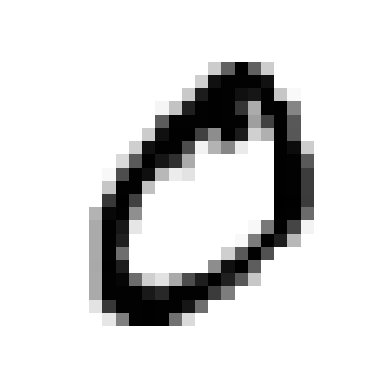

In [2]:
torch.manual_seed(1)

train_dataset = datasets.MNIST(root = "dataset/", train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root = "dataset/", train=False, transform=transforms.ToTensor(), download=True)

some_img, some_label = train_dataset[1]
print(len(train_dataset))
print(len(test_dataset))
print(some_img.shape)
plt.imshow(some_img[0,:,:], cmap='binary')
plt.axis('off')
plt.show()

Ở đây ta sẽ xây dựng một mô hình NN sử dụng thư viện Pytorch. Trong file utils.py có phần 'import torch.nn as nn', torch.nn bao gồm nhiều hàm thường được sử dụng mà người dùng có thể gọi ra thay vì phải xây dựng từ đầu, ví dụ như nn.Linear, nn.ReLU, nn.Sigmoid,....

Class nn.Module là một class cơ bản của Pytorch có sẵn hàm forward propagation (đưa x ở đầu vào mô hình và trả đầu ra y), backward propagation (tính toán gradient descent), save_state và load_state (lưu và nạp trạng thái của mô hình),... giúp việc xây dựng các mô hình theo ý muốn dễ dàng hơn.

Ví dụ dưới đây xây dựng mạng NN gồm 2 lớp Linear. Hàm nn.Linear() yêu cầu 2 tham số là in_features và out_features, in_features là số neural ở đầu vào còn out_features là số neural ở đầu ra. Vì mỗi ảnh có kích thước [1,28,28] nên số neural đầu vào lớp đầu tiên là 28x28=784, đầu ra ở lớp cuối là 10 neural ứng với 10 class.

Hãy hoàn thiện code mô hình NN 2 lớp ở dưới. Layers_dims là một list chứa số neural ở các lớp, vd: [784,20,10]

In [4]:
class LinearNN_2layer(nn.Module):
    def __init__(self, layers_dims):
        super().__init__()

        self.L1 = nn.Linear(in_features=layers_dims[0], out_features=layers_dims[1])
        self.relu = nn.ReLU()

        # Finish this code
        self.L2 = nn.Linear(in_features=layers_dims[1], out_features=layers_dims[2])
        self.sigmoid = nn.Sigmoid()
        # End

    def forward(self,x):
        x = self.relu(self.L1(x))
        x = self.sigmoid(self.L2(x))
        return x

Phần dưới sẽ là việc thiết lập DataLoader, loss, optimizer và các hyperparameter cho mô hình. Về module DataLoader và Dataset của Pytorch thì tạm thời chưa yêu cầu các em tìm hiểu sâu, hiểu đơn giản thì đây là công cụ giúp quá trình load data và tính toán trong máy tính nhanh, đơn giản và gọn hơn.

Batch_size, epoch/iteration, optimizer và stochastic gradient descent là gì?

In [5]:
batch_size = 32
num_epochs = 10
lr = 1e-3
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

model_NN2Layer = LinearNN_2layer([784,20,10])
CELoss = nn.CrossEntropyLoss()
optimizer_NN2Layer = optim.SGD(model_NN2Layer.parameters(), lr = lr)

Chạy code ở dưới để huấn luyện mô hình với các hyperparameter đã chọn và quan sát kết quả của mô hình.

In [5]:
trained_model, NN2Layer_acc_list = trainer(model_NN2Layer, train_loader, test_loader, num_epochs, batch_size, optimizer_NN2Layer, CELoss)
print(f'Linear NN with 2 layers: Train_acc: {NN2Layer_acc_list[-1][0]:.2f}%. Test_acc: {NN2Layer_acc_list[-1][1]:.2f}%.')

Epoch 1/10: Train_acc is 15.53%. Test_acc is 14.53%. Total loss is 4308.09
Epoch 2/10: Train_acc is 27.48%. Test_acc is 26.75%. Total loss is 4278.06
Epoch 3/10: Train_acc is 46.12%. Test_acc is 45.20%. Total loss is 4237.49
Epoch 4/10: Train_acc is 53.77%. Test_acc is 53.05%. Total loss is 4187.75
Epoch 5/10: Train_acc is 57.93%. Test_acc is 57.15%. Total loss is 4130.95
Epoch 6/10: Train_acc is 61.41%. Test_acc is 60.87%. Total loss is 4067.23
Epoch 7/10: Train_acc is 65.44%. Test_acc is 65.19%. Total loss is 3997.43
Epoch 8/10: Train_acc is 69.55%. Test_acc is 69.92%. Total loss is 3922.28
Epoch 9/10: Train_acc is 72.70%. Test_acc is 73.24%. Total loss is 3844.01
Epoch 10/10: Train_acc is 74.12%. Test_acc is 74.17%. Total loss is 3766.65
Linear NN with 2 layers: Train_acc: 74.12%. Test_acc: 74.17%.


# 2.2. Tweaking the hyperparameters

Phần này ta sẽ khảo sát sự ảnh hưởng của các hyperparameter đến hoạt động mô hình. Bước đầu tiên là xây dựng một NN có L lớp Linear, trong đó L-1 lớp đầu tiên dùng hàm kích hoạt ReLU và lớp cuối cùng dùng hàm Sigmoid.

model = nn.Sequential() là một chuỗi các hàm được thêm vào khi khởi tạo hoặc bởi model.add_module().
Về lý do sử dụng hàm này, xét trường hợp NN 2 lớp ***INPUT -> LINEAR -> RELU -> LINEAR -> SIGMOID -> OUTPUT***, thay vì phải gọi lần lượt từng hàm L1, ReLU, L2, Sigmoid như trên thì ta có thể xây dựng

    model = nn.Sequential()
    model.add_module('L1',nn.Linear(in_features=2,out_features=10))
    model.add_module('Acti1',nn.ReLU())
    model.add_module('L2',nn.Linear(in_features=10,out_features=1))
    model.add_module('Acti2',nn.Sigmoid())


và sau đó gọi output = model(input).

Phần bài tập dưới đây, hãy xây dựng một mạng NN gồm L lớp Linear. (ở đây đặt lớp Sigmoid ở cuối ra ngoài nn.Sequential() để tiện visualize).

Đầu vào ở lớp Linear đầu tiên là 28x28=784, đầu ra ở lớp Linear cuối cùng là 1.
Đầu vào ở lớp Linear thứ l bằng layers_dims[l], đầu ra là layers_dims[l+1].

In [17]:
class LinearNN(nn.Module):
    def __init__(self, L, layers_dims):
        '''
            L: number of linear layers
            layers_dims: list containing the input size and each layer size, of length (number of layers + 1)
        '''
        super().__init__()
        if len(layers_dims) != L+1:
            raise ValueError(f"Length of layers_dims must be L+1. Expected len(layers_dims)={L+1}, got {len(layers_dims)}")
        self.model = nn.Sequential()

        # INSERT CODE HERE
        for layer in range(L-1):
            self.model.add_module(f'Linear {layer}', nn.Linear(layers_dims[layer], layers_dims[layer+1]))
            self.model.add_module(f'Acti {layer}', nn.ReLU())

        self.model.add_module(f'Linear {L}',nn.Linear(layers_dims[L-1], layers_dims[L]))
        # END CODE HERE

        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        return self.sigmoid(self.model(x))

    def visualize_pca(self, loader):
        '''
            Use this function to visualize features using PCA
        '''
        fea_list = []
        classes = [0,1,2,3,4,5,6,7,8,9]
        self.model.eval()
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        with torch.no_grad():
            for data, target in loader:
                data = data.view(data.shape[0],-1)

                data = data.to(device = DEVICE)
                target = target.to(device = DEVICE)

                fea = self.model(data)

                batch_data = torch.hstack((target.unsqueeze(-1),fea))
                fea_list.append(batch_data)

        fea_list = torch.cat(fea_list, dim=0) # size (num_samples,label+features)
        fea_list = fea_list.cpu().numpy()
        u,_,_ = torch.pca_lowrank(fea_list[:,1:],center=False)

        data_points = torch.hstack((fea_list[:,0].unsqueeze(-1), u[:,:2]))

        fig = plt.figure()
        ax = plt.subplot(111)
        for label in classes:
            scat = [point for point in data_points if point[0]==label]
            scat = np.stack(scat,dim=0)
            ax.scatter(scat[:,1],scat[:,2], label=f'{label}')

        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

        if loader.dataset.train:
            ax.set_title("Visualize features on train dataset")
        else:
            ax.set_title("Visualize features on test dataset")
        plt.grid()
        plt.show()

        self.model.train()
        return

    def visualize_tsne(self, loader):
        '''
            Use this function to visualize features using PCA
        '''
        fea_list = []
        classes = [0,1,2,3,4,5,6,7,8,9]
        self.model.eval()
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        with torch.no_grad():
            for data, target in loader:
                data = data.view(data.shape[0],-1)

                data = data.to(device = DEVICE)
                target = target.to(device = DEVICE)

                fea = self.model(data)

                batch_data = torch.hstack((target.unsqueeze(-1),fea))
                fea_list.append(batch_data)

        fea_list = torch.cat(fea_list, dim=0) # size (num_samples,label+features)
        fea_list = fea_list.cpu().numpy()
        tsne = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)
        tsne_results = tsne.fit_transform(fea_list)

        data_points = torch.hstack((fea_list[:,0].unsqueeze(-1), torch.from_numpy(tsne_results)))

        fig = plt.figure()
        ax = plt.subplot(111)
        for label in classes:
            scat = [point for point in data_points if point[0]==label]
            scat = np.stack(scat,dim=0)
            ax.scatter(scat[:,1],scat[:,2], label=f'{label}')

        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

        if loader.dataset.train:
            ax.set_title("Visualize features on train dataset")
        else:
            ax.set_title("Visualize features on test dataset")
        plt.grid()
        plt.show()

        self.model.train()
        return

Chạy đoạn code dưới đây để kiểm tra hoạt động của mô hình.

Expected results: Train_acc và Test_acc tăng lên khi train.

Từ mô hình trên, hãy thay đổi các hyperparameter (batch_size, epoch, L, layers_dims), tổng hợp kết quả và nhận xét.

In [8]:
# Change these
L = 2
layers_dims = [784,50,10]
num_epochs = 1
batch_size = 32
# End

model = LinearNN(L, layers_dims)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)
optimizer = optim.SGD(model.parameters(), lr = lr)

trained_model, acc_list = trainer(model, train_loader, test_loader, num_epochs, batch_size, optimizer, CELoss)

Epoch 1/1: Train_acc is 33.88%. Test_acc is 33.95%. Total loss is 4292.29


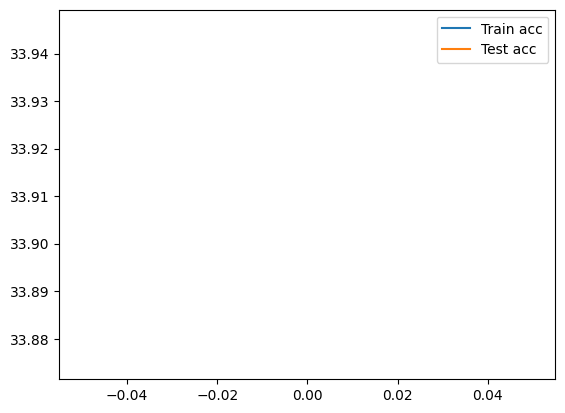

In [9]:
plot_acc_curve(acc_list)

In [10]:
trained_model.visualize_tsne(test_loader)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [ ]:
trained_model.visualize_pca(test_loader)

# 3. What could go wrong?

Dưới đây ta sẽ chỉ xét bài toán phân lớp nhị phân: Nhận dạng là chữ số 5 hoặc không là chữ số 5. Bắt đầu với trường hợp chỉ sử dụng NN 2 lớp.

Vì là phân lớp nhị phân nên đầu ra sẽ chỉ cần 1 neural, trong Pytorch thì ta sẽ dùng BCELoss() thay cho CrossEntropyLoss khi đầu ra chỉ có 1 neural.

In [8]:
batch_size = 32
num_epochs = 1
lr = 1e-3

model_pred5 = LinearNN_2layer([784,20,1])
BCELoss = nn.BCELoss() # CrossEntropyLoss for single output NN
optimizer_pred5 = optim.SGD(model_pred5.parameters(), lr = lr)

trained_model_pred5, pred5_acc_list = trainer_pred5(model_pred5, train_loader, test_loader, num_epochs, batch_size, optimizer_pred5, BCELoss)
print(f'Linear NN with 2 layers for \'5\' prediction: Train_acc: {pred5_acc_list[-1][0]:.2f}%. Test_acc: {pred5_acc_list[-1][1]:.2f}%')

Epoch 1/1: Train_acc is 90.96%. Test_acc is 90.93%. Total loss is 695.45
Linear NN with 2 layers for '5' prediction: Train_acc: 90.96%. Test_acc: 90.93%


Vậy mô hình của chúng ta có kết quả như thế nào? Chỉ với 1 epoch mà mô hình đã có thể đạt độ chính xác rất cao. Để điều tra tình huống này thì hãy xét một dummy_predictor như ở dưới.

Bài tập 3.1: Mô hình dưới đây đang dự đoán bằng cách nào? Tại sao mô hình này lại có hiệu quả? Gợi ý: xem phân bố về số lượng của các nhãn.

Vậy chúng ta giải quyết vấn đề này như thế nào?

Bài tập 3.2: Precision, Recall, F1 Score, ROC, AUC là gì?

In [15]:
class dummy_predictor(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.zeros(x.shape[0], device=x.device).unsqueeze(-1)

dummy = dummy_predictor().to(device='cuda')
dummy_train_acc = check_accuracy_pred5(train_loader, dummy, batch_size)
dummy_test_acc = check_accuracy_pred5(test_loader, dummy, batch_size)
print(f'Dummy model: Train_acc: {dummy_train_acc:.2f}%. Test_acc: {dummy_test_acc:.2f}%.')

cuda:0
Dummy model: Train_acc: 90.96%. Test_acc: 90.93%.


# 4. Overfitting

Chạy mô hình dưới đây và đánh giá kết quả của mô hình này.

In [44]:
labels = [0,1,2,3,4,5,6,7,8,9]
idx = []
for label in labels:
    label_bin = torch.where(train_dataset.targets == label, 1, 0)
    label_idx = torch.argwhere(label_bin)
    idx.append(label_idx[:500])
idx = torch.cat(idx)

L = 10
layers_dims = [784,4096,2048,1024,512,256,128,64,32,16,10]
num_epochs = 100
batch_size = 64
lr = 1e-3

model = LinearNN(L, layers_dims)
CELoss = nn.CrossEntropyLoss()
mini_train_dataset = datasets.MNIST(root = "dataset/", train=True, transform=transforms.ToTensor(), download=True)

mini_train_dataset.data = train_dataset.data[[int(i) for i in idx]]
mini_train_dataset.targets = train_dataset.targets[[int(i) for i in idx]]
mini_train_loader = DataLoader(mini_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)
optimizer = optim.SGD(model.parameters(), lr = lr)

In [ ]:
mini_trained_model, mini_acc_list = trainer(model, mini_train_loader, test_loader, num_epochs, batch_size, optimizer, CELoss)

Epoch 1/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3032707202
Epoch 2/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3032855535
Epoch 3/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3033525008
Epoch 4/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3031345168
Epoch 5/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3031634319
Epoch 6/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3031610145
Epoch 7/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3034488612
Epoch 8/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3032242165
Epoch 9/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3033265011
Epoch 10/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3034466098
Epoch 11/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.3034103762
Epoch 12/100: Train_acc is 9.89%. Test_acc is 10.23%. Train avg loss is 2.

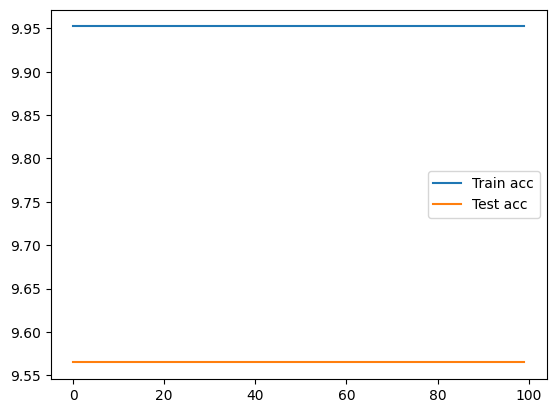

In [18]:
plot_acc_curve(mini_acc_list)


Nhóm data 1 (viết sẵn các hàm load data, vẽ kq). Visualize features bằng PCA. Cho thử giải thích các tình huống kết quả và giới thiệu ROC, AUC.
Batch size, epoch/iteration, optimizer, stochastic gradient descent là gì. Việc thay đổi các thành phần này ảnh hưởng như thế nào đến kết quả, cho ví dụ minh họa bằng MNIST dataset ở trên.

Tinh chỉnh số lượng neuron trong mỗi lớp và số lớp neuron, đưa ra các kq và phân tích
Đối với model bị overfit, gợi ý về l2 regularization